# Plaquette results


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from series import calculate_coeffs, partial_sum, estimate_radius
from plot_complex import complex_array_to_rgb
from hubbard_sc_exp import HubbardED
plt.rcParams['figure.dpi'] = 200
import tqdm

In [86]:
def Z_atomic(U:float, beta:float, mu:float):

    return 1+2*np.exp(beta*mu)+np.exp(beta*(2*mu - U))


def get_neighbors_and_t_plaquette_uncoupled(t):

    neighbors = [(0,1,t), (0,2,t), (1,3,t), (2,3,t)]

    return neighbors


def partition_plaquette_complex(t,U,beta,mu, neighbors_func):
    """Computes Z for the plaquette with complex t."""

    Z = np.zeros_like(t, dtype=np.complex128)
    for i in tqdm.tqdm(range(t.shape[0]), desc="Rows"):
        for j in range(t.shape[1]):

            neighbors = neighbors_func(t[i,j])
            Es = hubbard.full_spectrum(U,mu,neighbors)
            Z[i,j] = np.sum(np.exp(-beta*Es))

    return Z


def logZ_plaquette(t,U,beta,mu, neighbors_func):

    Z = np.zeros_like(t)

    for i,z in enumerate(t): 
        neighbors = neighbors_func(z)
        Es = hub.full_spectrum(U,mu,neighbors)
        Z[i] = np.sum(np.exp(-beta*Es))
    
    return -1/(4*beta)*np.log(Z)

#create a meshgrid of complex hopping values from a to b. 
def get_tgrid(a:float, b:float, npoints:int):
    treal = np.linspace(a, b, npoints)
    tr, ti = np.meshgrid(treal, treal)
    return tr + 1j*ti

In [87]:
hub = HubbardED(4)

In [88]:
U = 6.0
beta = 1.0
mu = 2.0
r = 0.5 # radius for the complex plane plot
N = 200 # number of points in the circle of radius r to sample

a = -1.5
b = 1.5

In [89]:
ts = np.linspace(0,2.0)

orders =[2,4,6,8]
data = {order:  partial_sum(ts, N, logZ_plaquette, order, r, U, beta, mu, get_neighbors_and_t_plaquette_uncoupled) for order in orders}

Text(0.5, 1.0, '$\\Omega(U, t, \\beta, \\mu)$ for plaquette')

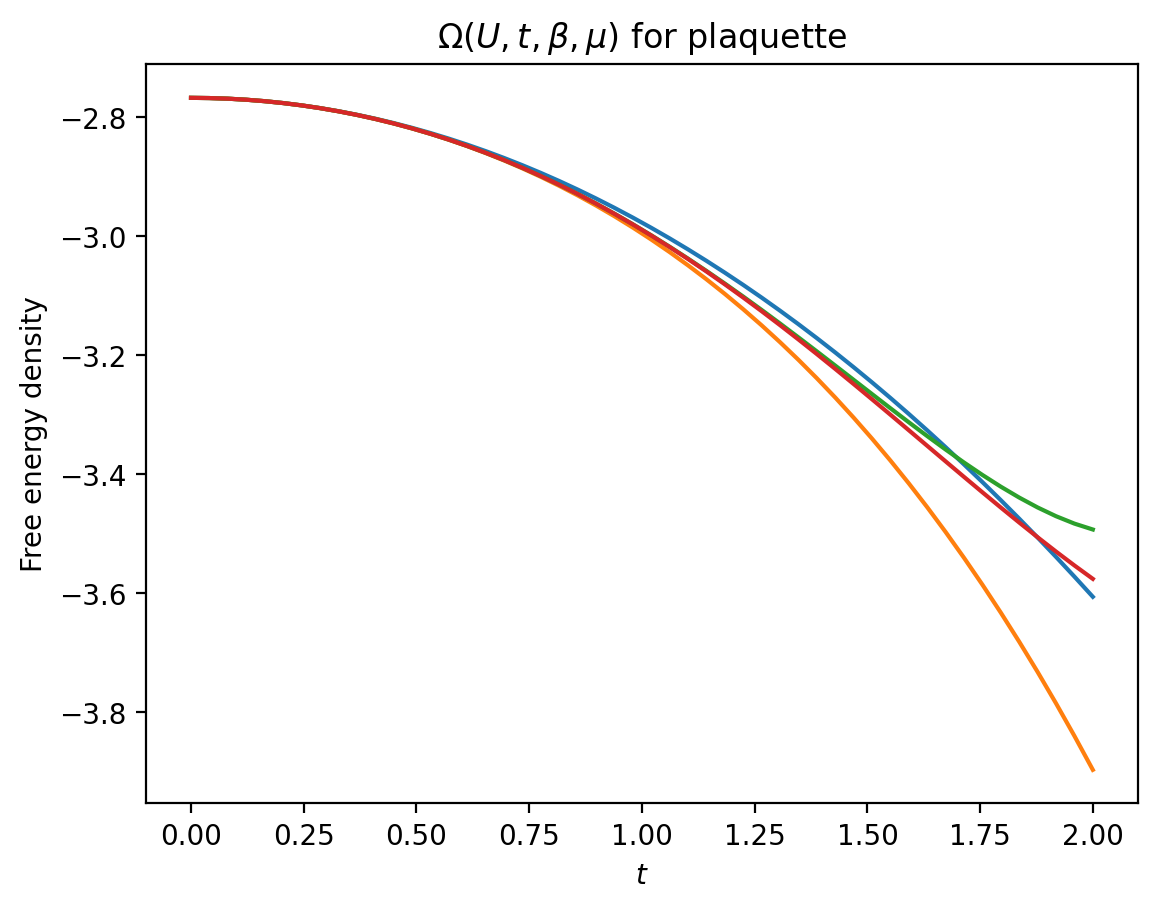

In [90]:
for order in orders:
    plt.plot(ts, data[order].real, label=f"Order {order}")

plt.xlabel("$t$")
plt.ylabel("Free energy density")
plt.title(r"$\Omega(U, t, \beta, \mu)$ for plaquette")

In [ ]:
def Omega2_exact(U:float, beta:float, mu:float):
    
    Zat = Z_atomic(U, beta, mu)

    fact = np.exp(beta*mu)/Zat**2
    A = beta**2/2*(1+np.exp(-beta*(U-2*mu)))
    B = 2*beta/U*np.exp(-beta*(U/2-mu))*np.sinh(beta*U/2)
    return -2/beta*fact*(A+B)*2 #factor 2 for spin and 2 for sites!

In [95]:
ans = calculate_coeffs(N, logZ_plaquette, 10,r, U, beta, mu, get_neighbors_and_t_plaquette_uncoupled)

In [96]:
ans[2], Omega2_exact(U, beta, mu)

(np.complex128(-0.2096316312744435-5.684341886080802e-16j),
 np.float64(0.20963163127444406))